In [1]:
import sys
sys.path.append("../../src/")

from project_imports import *
import numerical_quenches as nq



In [2]:
def uv(alpha,beta,u,v):
    ut = alpha*u +beta*v
    vt = alpha*v + beta*u
    return ut,vt

def g(t,args):
    g0=args
    return g0

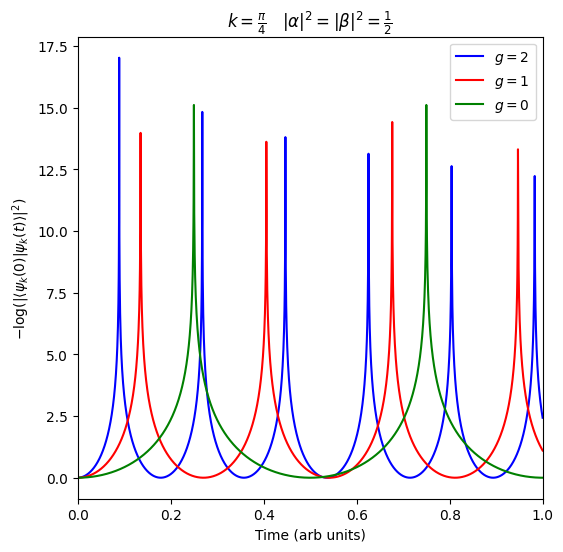

In [3]:
#Pre Reqs
k = pi/4

g0s = [2,1,0]
colors = ["blue","red","green"]
plt.figure(figsize=(6,6))
title(r"$k=\frac{\pi}{4}$   $|\alpha|^2=|\beta|^2=\frac{1}{2}$")
for g0,c in zip(g0s,colors):
    t_eval = np.linspace(0,pi,3000)


    H = nq.BdG(k,g0)
    E, V = np.linalg.eigh(H)   # Hermitian diagonalization
    idx = np.argmin(E)         # negative eigenvalue
    vec = V[:,idx]
    u0, v0 = vec[0], vec[1]
    alpha, beta = sqrt(1/2), sqrt(1/2)
    ut,vt= uv(alpha,beta,u0,v0)
    u,v=nq.evolve_mode(k,g,t_eval,ut,vt,g0)
    plot(t_eval/pi,-log(np.abs(np.conj(u[0])*u+np.conj(v[0])*v)**2),label=rf"$g={g0}$",color=c)


xlim(t_eval[0],t_eval[-1]/pi)
xlabel("Time (arb units)")
ylabel(r"$-\log(|\langle \psi_k(0) | \psi_k(t) \rangle|^2)$")
legend()
plt.savefig("SingleModeFreeEvolutionDQPT.png",dpi=500)

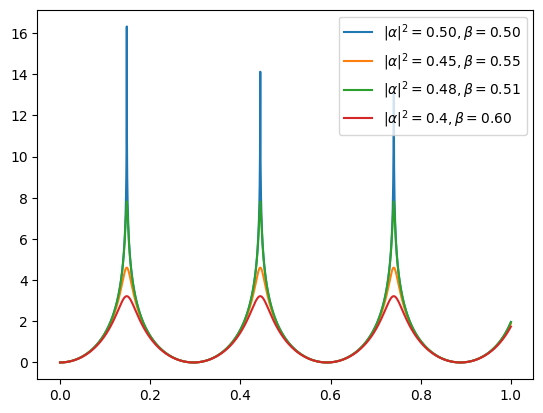

In [117]:
weights = [ (sqrt(1/2),sqrt(1/2)), (sqrt(.45), sqrt(.55)), (sqrt(.49), sqrt(.51)),(sqrt(.4),sqrt(.6)) ]
for weight in weights:
    alpha, beta = weight
    ut,vt= uv(alpha,beta,u0,v0)
    u,v=nq.evolve_mode(k,g,t_eval,ut,vt,_)
    plot(t_eval/pi,-log(np.abs(np.conj(u[0])*u+np.conj(v[0])*v)**2),label=rf"$|\alpha|^2={str(np.abs(alpha)**2)[:4]}, \beta={str(np.abs(beta)**2)[:4]}$")

legend()

In [4]:
import numpy as np

def omega_q(g, q):
    return np.sqrt(g**2 + 2*g*np.cos(q) + 1)

def u_q(g, q):
    a = g + np.cos(q)
    w = omega_q(g, q)
    denom = np.sqrt(2*w*(w - a))
    return (a - w) / denom

def v_q(g, q):
    b = np.sin(q)
    w = omega_q(g, q)
    a = g + np.cos(q)
    denom = np.sqrt(2*w*(w - a))
    return b / denom

  0%|          | 0/20 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_87425/2345712462.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return (a - w) / denom
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_87425/2345712462.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return b / denom
100%|██████████| 20/20 [00:07<00:00,  2.77it/s]


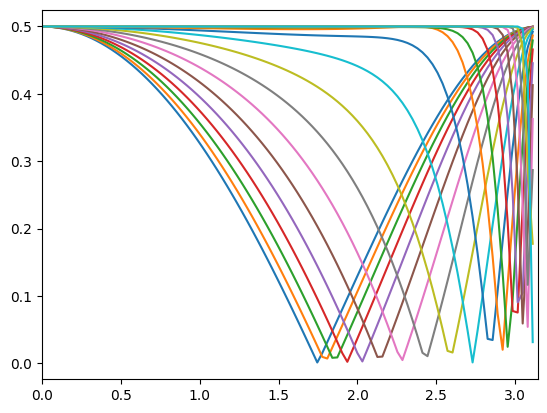

In [5]:
import kibble_zurek as kz

ks = np.linspace(0,pi,100)
taus= np.logspace(-2,2,20)
k_min=[]
for tau in tqdm(taus):
    dat=[]
    for k in ks:
        u,v= kz.u_tilde(tau,k,tau),kz.v_tilde(tau,k,tau)
        u0, v0 = u_q(0,pi-k),v_q(0,pi-k)
        alpha = u0*u+1j*v*v0
        dat.append(abs(abs(np.abs(alpha)**2)-1/2))

    dat=array(dat)
    plot(ks,dat)
    #ylim(0,1)
    xlim(0,pi)

    idx = np.argmin(dat)

    k_min.append(ks[idx])

k_min=array(k_min)

[]

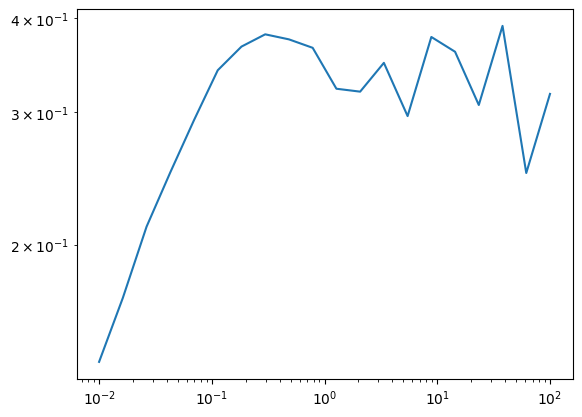

In [6]:
plot(taus,(pi-array(k_min))*taus**(1/2))
loglog()

In [284]:
pi-1000000000000**(-1/2)/3

3.1415923202564597

In [312]:
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm
import kibble_zurek as kz

ks   = np.linspace(0, np.pi, 1000)
taus = np.logspace(1, 1.2, 30)

def compute_for_k(k, tau):
    u  = kz.u_tilde(tau, k, tau)
    v  = kz.v_tilde(tau, k, tau)
    u0 = u_q(0, np.pi - k)
    v0 = v_q(0, np.pi - k)

    alpha = u0*u + 1j*v*v0
    return abs(v0)

k_min = []

for tau in tqdm(taus):

    dat = Parallel(n_jobs=-1)(
        delayed(compute_for_k)(k, tau) for k in ks
    )

    dat = np.array(dat)

    idx = np.argmin(dat)
    k_min.append(ks[idx])

k_min = np.array(k_min)

  0%|          | 0/30 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_81582/2345712462.py:10: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_81582/2345712462.py:17: RuntimeWarning: invalid value encountered in scalar divide
  3%|▎         | 1/30 [00:01<00:36,  1.24s/it]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_81582/2345712462.py:10: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_81582/2345712462.py:17: RuntimeWarning: invalid value encountered in scalar divide
  7%|▋         | 2/30 [00:01<00:20,  1.39it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_81582/2345712462.py:10: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_81582/2345712462.py:17: RuntimeWarning: invalid value encountered in scalar divide
 10%|█         | 3

KeyboardInterrupt: 

[]

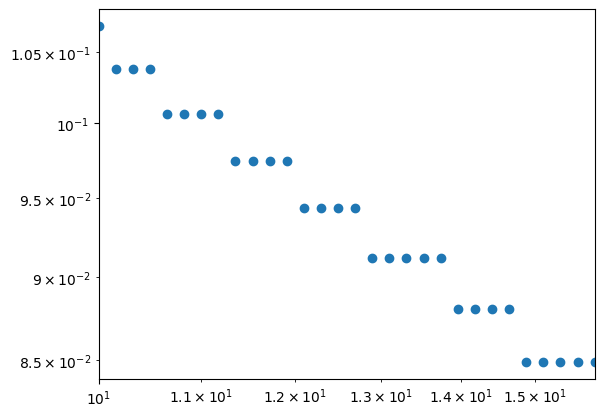

In [309]:
scatter(taus,(pi-array(k_min)))
xlim(10,taus[-1])
loglog()

In [310]:
import numpy as np

x = taus
y = np.pi - np.array(k_min)
# remove zeros if any
mask = x > 1
x_fit = x[mask]
y_fit = y[mask]

# compute best prefactor a
a = np.mean(y_fit * np.sqrt(x_fit))

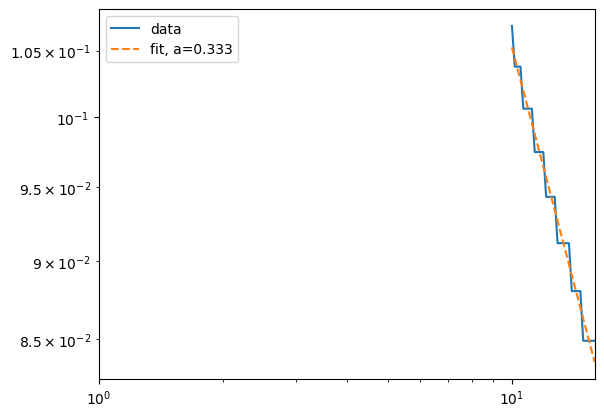

In [311]:
import matplotlib.pyplot as plt

plt.loglog(taus, y, label="data")
plt.loglog(taus, a*taus**(-1/2), "--", label=f"fit, a={a:.3g}")

plt.xlim(1, taus[-1])
plt.legend()
plt.show()

In [305]:
pi- 2*a*10**(-1/2)

np.float64(2.9323874859825554)

  5%|▌         | 5/100 [00:03<01:11,  1.33it/s]


KeyboardInterrupt: 

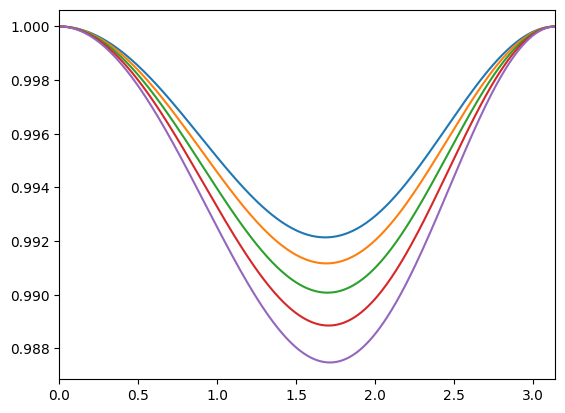

In [328]:
import kibble_zurek as kz

ks = np.linspace(0,pi,300)
taus= np.logspace(-2,3,100)
k_min=[]
for tau in tqdm(taus):
    dat=[]
    for k in ks:
        v= kz.v_tilde(tau,k,tau)
        v0= kz.v_tilde(tau,k,-1000)
        dat.append(abs(np.conj(v0)*v))

    dat=array(dat)
    plot(ks,dat)
    #ylim(0,1)
    xlim(0,pi)

    idx = np.argmin(dat)

    k_min.append(ks[idx])

k_min=array(k_min)

In [352]:
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm
import kibble_zurek as kz

ks = np.logspace(np.log10(pi/2), np.log10(pi), 1000)
taus = np.logspace(2, 3, 10)

def compute_kmin(tau):
    dat = []
    for k in ks:
        v  = kz.v_tilde(tau, k, tau)
        v0 = kz.v_tilde(tau, k, -1000)
        dat.append(abs(np.conj(v0) * v))
    dat = np.array(dat)
    idx = np.argmin(dat)
    return ks[idx], dat  # return dat if you still want to plot

results = Parallel(n_jobs=-1)(
    delayed(compute_kmin)(tau) for tau in tqdm(taus)
)

k_min = np.array([r[0] for r in results])

100%|██████████| 10/10 [00:00<00:00, 16892.08it/s]


[]

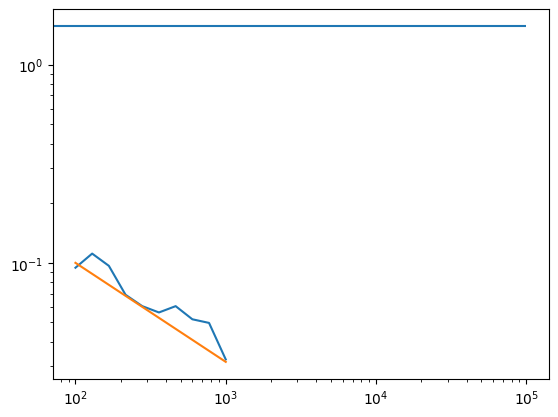

In [353]:
plot(taus,pi-k_min)
plot(taus,taus**(-1/2))
plt.hlines(pi/2,0,100000)
loglog()

a = 0.7908513087355624
b = 0.434223782292715


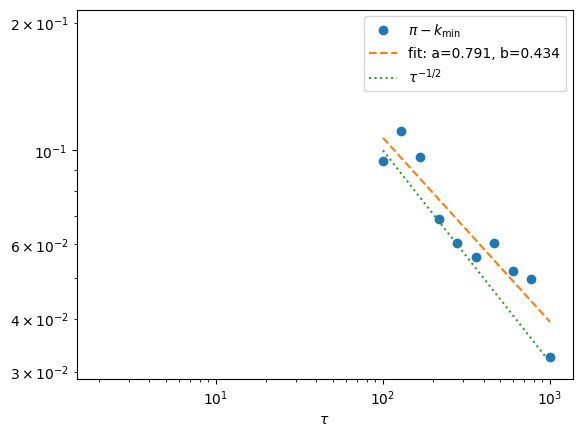

In [354]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----- data -----
ydata = np.pi - k_min

# ----- mask option -----
def fit_power_law(taus, ydata, tau_min=None):
    """
    Fits y = a * tau^(-b)
    tau_min : only fit data with tau > tau_min
    """
    if tau_min is not None:
        mask = taus > tau_min
        taus_fit = taus[mask]
        y_fit = ydata[mask]
    else:
        taus_fit = taus
        y_fit = ydata

    def model(tau, a, b):
        return a * tau**(-b)

    popt, pcov = curve_fit(model, taus_fit, y_fit, p0=(1.0, 0.5))
    a, b = popt
    return a, b, taus_fit

# ---- choose cutoff here ----
tau_cut = 10   # set None if you want full fit

a, b, taus_fit = fit_power_law(taus, ydata, tau_min=tau_cut)

print("a =", a)
print("b =", b)

# ----- plotting -----
plt.figure()

plt.loglog(taus, ydata, 'o', label=r"$\pi-k_{\min}$")
plt.loglog(taus, a * taus**(-b), '--', label=rf"fit: a={a:.3f}, b={b:.3f}")

# reference 1/sqrt(tau)
plt.loglog(taus, taus**(-1/2), ':', label=r"$\tau^{-1/2}$")

plt.hlines(np.pi/2, taus.min(), taus.max())

plt.xlabel(r"$\tau$")
plt.legend()
plt.show()

In [356]:
taus[3]

np.float64(215.44346900318845)

In [357]:
taus[-1]

np.float64(1000.0)

In [358]:
ydata[3]

np.float64(0.06898385228542026)

In [359]:
ydata[-1]

np.float64(0.03252693034798959)